In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mab_utils import *

In [2]:
# Initialize agents and testbed param function
n_arms = 10

simple_bandit = SimpleBandit(n_arms, np.ones(n_arms)*0, 0.1)
exp_bandit = ExponentialBandit(n_arms, np.ones(n_arms)*0, 0.1)
ucb_bandit = UcbBandit(n_arms, np.ones(n_arms)*0, 2)
agent_dict = {'simple_bandit': simple_bandit,
              'exp_bandit': exp_bandit,
              'ucb_bandit': ucb_bandit}

testbed = TestBed(n_arms)

In [3]:
# Run agents
agent_output = {}
for agent in agent_dict.keys():
    action_log, testbed_log = bandit_simulation(agent_dict[agent], testbed, time_steps = 1000, epochs = 200)
    agent_output[agent] = {'action_log': action_log, 'testbed_log': testbed_log}

print(agent_output['simple_bandit']['action_log'][0])

[[ 0.         -1.11332876  0.        ]
 [ 1.          0.95737043  0.        ]
 [ 1.         -0.49148261  0.        ]
 ...
 [ 2.         -0.50919885  1.        ]
 [ 2.          2.81634544  1.        ]
 [ 2.          1.34575793  1.        ]]


In [4]:
print(agent_output['simple_bandit']['testbed_log'][0])

{'means': array([ 0.54762916,  0.72404788,  1.41727051,  0.01149999, -0.72233872,
        0.82504099,  0.35139931, -1.98626079,  0.61857196, -0.5852481 ]), 'vars': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), 'optimal_action': np.int64(2)}


In [5]:
#avg_reward = np.average(agent_output['simple_bandit']['action_log'][:, :, 1], axis = 0)
avg_reward = np.average(agent_output['exp_bandit']['action_log'][:, :, 1], axis = 0)

In [6]:
avg_agent_rewards = []

for agent in agent_dict.keys():
    avg_agent_rewards.append(pd.Series(np.mean(agent_output[agent]['action_log'][:, :, 1], axis = 0)))

df = pd.concat(avg_agent_rewards, axis=1)
df.columns = agent_dict.keys()

df

,simple_bandit,exp_bandit,ucb_bandit
0,-0.283759,0.092909,0.042810
1,-0.000703,0.350914,-0.027173
2,0.313339,0.357913,0.031658
3,0.429435,0.621685,-0.072985
4,0.552452,0.595573,0.096621
...,...,...,...
995,1.088725,1.497769,1.405934
996,1.331825,1.239952,1.409657
997,1.271881,1.283471,1.472047
998,1.337218,1.504952,1.501909


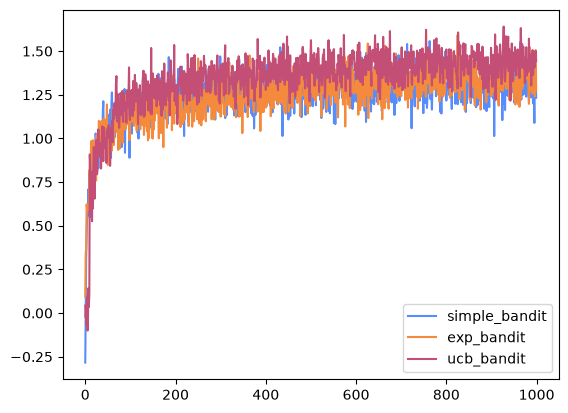

In [7]:
fig, ax = plt.subplots()
for col in df.columns:
    plt.plot(df[col], label=col)
ax.legend()

In [8]:
agent_output['ucb_bandit']['action_log']

array([[[ 3.        , -0.60125721,  0.        ],
        [ 1.        , -3.97213573,  0.        ],
        [ 4.        , -1.71967401,  0.        ],
        ...,
        [ 5.        ,  2.76147582,  1.        ],
        [ 5.        ,  1.61775281,  1.        ],
        [ 5.        , -0.67091806,  1.        ]],

       [[ 5.        ,  0.52752277,  0.        ],
        [ 8.        ,  1.84361595,  1.        ],
        [ 3.        ,  1.35157263,  0.        ],
        ...,
        [ 8.        ,  2.02646604,  1.        ],
        [ 8.        ,  1.57618392,  1.        ],
        [ 8.        ,  1.60111519,  1.        ]],

       [[ 8.        , -1.02736875,  0.        ],
        [ 1.        , -0.19910907,  0.        ],
        [ 4.        , -0.37639398,  0.        ],
        ...,
        [ 6.        ,  0.5369209 ,  0.        ],
        [ 6.        ,  0.05892806,  0.        ],
        [ 6.        ,  0.14717356,  0.        ]],

       ...,

       [[ 8.        ,  0.70364446,  1.        ],
        [ 0